# EDA — IEEE-CIS Fraud Detection

Análisis exploratorio completo del dataset de la competición
[IEEE-CIS Fraud Detection](https://www.kaggle.com/competitions/ieee-fraud-detection/data).

## Descripción del dataset

El dataset proviene de transacciones de e-commerce reales proporcionadas por Vesta Corporation.
Se divide en dos tablas unidas por `TransactionID`:

**Transaction table** (~590K train, ~506K test):

- `TransactionDT` — timedelta desde una fecha de referencia (no es timestamp real)
- `TransactionAmt` — monto de la transacción (USD)
- `ProductCD` — código de producto (W, H, C, S, R)
- `card1`–`card6` — información de la tarjeta de pago (tipo, categoría, banco emisor)
- `addr1`, `addr2` — dirección de facturación (zip code, país/región)
- `dist1`, `dist2` — distancias entre ubicaciones de transacción
- `P_emaildomain`, `R_emaildomain` — dominio de email del comprador/receptor
- `C1`–`C14` — features de conteo (ej: direcciones asociadas a la tarjeta)
- `D1`–`D15` — timedeltas (ej: días desde transacciones previas)
- `M1`–`M9` — features de match (ej: nombre en tarjeta vs dirección)
- `V1`–`V339` — features numéricas engineered por Vesta (muchas sparse)

**Identity table** (~144K train, ~141K test):

- `id_01`–`id_38` — información de identidad (red, firma digital)
- `DeviceType` — tipo de dispositivo (mobile, desktop)
- `DeviceInfo` — info del dispositivo (navegador, OS, modelo)

**Target**: `isFraud` — 1 si la transacción es fraudulenta, 0 si no.

## Estructura del notebook

1. **Fase 1**: Familiarización con los datos
2. **Fase 2**: Descubrimiento de patrones (temporal, segmentación, relaciones)
3. **Fase 3**: Investigación de anomalías
4. **Fase 4**: Generación de insights
5. **Fase 5**: Formulación de preguntas


---

## Setup e Imports


In [2]:
import gc
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# Ruta local a los datos
DATA_DIR = Path("../ieee-fraud-detection")
assert DATA_DIR.exists(), f"Data dir not found: {DATA_DIR.resolve()}"

print(f"Data dir: {DATA_DIR.resolve()}")
print("Files:", [f.name for f in DATA_DIR.iterdir()])

Data dir: C:\Users\jeffr\GitHub\ptdia-proyecto1\ieee-fraud-detection
Files: ['sample_submission.csv', 'test_identity.csv', 'test_transaction.csv', 'train_identity.csv', 'train_transaction.csv']


---

## Funciones utilitarias

Adaptadas de `02_kaggle_kernels/eda/main.py`.


In [ ]:
def reduce_memory(df):
    """Reduce memory usage by downcasting numeric types and converting low-cardinality strings to category."""
    for col in df.columns:
        if pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="float")
        elif df[col].dtype == "object":
            nunique = df[col].nunique(dropna=True)
            if nunique < max(1000, 0.5 * len(df)):
                df[col] = df[col].astype("category")
    return df


def add_time_features(df):
    """Derive day, week, hour, month proxy from TransactionDT."""
    df = df.copy()
    df["DT_day"] = (df["TransactionDT"] // (24 * 3600)).astype("int16")
    df["DT_week"] = (df["DT_day"] // 7).astype("int16")
    df["DT_hour"] = ((df["TransactionDT"] // 3600) % 24).astype("int8")
    df["DT_month_proxy"] = (df["DT_day"] // 30).astype("int8")
    return df


def candidate_uid(df):
    """Build candidate user ID from card + address + D1 anchor."""
    day = (df["TransactionDT"] // (24 * 3600)).astype("float32")
    parts = pd.DataFrame(index=df.index)
    for col in ["card1", "card2", "card3", "card5", "addr1", "addr2"]:
        parts[col] = df[col].astype("string").fillna("NA")
    parts["D1_anchor"] = (
        (df["D1"].astype("float32") - day).round(0).astype("string").fillna("NA")
    )
    return pd.util.hash_pandas_object(parts, index=False).astype("uint64")

---

## Carga de datos


In [57]:
print("Cargando train_transaction.csv ...")
train_txn = reduce_memory(pd.read_csv(DATA_DIR / "train_transaction.csv"))
print(f"  shape: {train_txn.shape}")

print("Cargando test_transaction.csv ...")
test_txn = reduce_memory(pd.read_csv(DATA_DIR / "test_transaction.csv"))
print(f"  shape: {test_txn.shape}")

print("Cargando train_identity.csv ...")
train_id = reduce_memory(pd.read_csv(DATA_DIR / "train_identity.csv"))
print(f"  shape: {train_id.shape}")

print("Cargando test_identity.csv ...")
test_id = reduce_memory(pd.read_csv(DATA_DIR / "test_identity.csv"))
print(f"  shape: {test_id.shape}")

Cargando train_transaction.csv ...
  shape: (590540, 394)
Cargando test_transaction.csv ...
  shape: (506691, 393)
Cargando train_identity.csv ...
  shape: (144233, 41)
Cargando test_identity.csv ...
  shape: (141907, 41)


In [58]:
train_txn.head(100)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,1.0000,1.0000,14.0000,NaN,13.0000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,...,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,...,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0000,W,18132,567.0000,150.0000,mastercard,117.0000,debit,476.0000,87.0000,NaN,NaN,yahoo.com,NaN,2.0000,5.0000,0.0000,0.0000,0.0000,4.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,25.0000,1.0000,112.0000,112.0000,0.0000,94.0000,0.0000,NaN,NaN,NaN,NaN,...,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,50.0000,1758.0000,925.0000,0.0000,354.0000,0.0000,135.0000,0.0000,0.0000,0.0000,50.0000,1404.0000,790.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0000,H,4497,514.0000,150.0000,mastercard,102.0000,credit,420.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,2987005,0,86510,49.0000,W,5937,555.0000,150.0000,visa,226.0000,debit,272.0000,87.0000,36.0000,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,...,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0000,W,12308,360.0000,150.0000,visa,166.0000,debit,126.0000,87.0000,0.0000,NaN,yahoo.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,...,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5000,W,12695,490.0000,150.0000,visa,226.0000,debit,325.0000,87.000

In [ ]:
train_id.head(10)

In [60]:
# Merge transaction + identity
train = train_txn.merge(train_id, on="TransactionID", how="left")
test = test_txn.merge(test_id, on="TransactionID", how="left")
del train_txn, test_txn, train_id, test_id
gc.collect()

# Marcar dataset y agregar features temporales
train["dataset"] = "train"
test["dataset"] = "test"
test["isFraud"] = np.nan

train = add_time_features(train)
test = add_time_features(test)

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

Train: (590540, 439)
Test:  (506691, 439)


In [67]:
train.head(100)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,dataset,DT_day,DT_week,DT_hour,DT_month_proxy
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,1.0000,1.0000,14.0000,NaN,13.0000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,1,0,0,0
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,1,0,0,0
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,1,0,0,0
3,2987003,0,86499,50.0000,W,18132,567.0000,150.0000,mastercard,117.0000,debit,476.0000,87.0000,NaN,NaN,yahoo.com,NaN,2.0000,5.0000,0.0000,0.0000,0.0000,4.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,25.0000,1.0000,112.0000,112.0000,0.0000,94.0000,0.0000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,1,0,0,0
4,2987004,0,86506,50.0000,H,4497,514.0000,150.0000,mastercard,102.0000,credit,420.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,100.0000,NotFound,NaN,-480.0000,New,NotFound,166.0000,NaN,542.0000,144.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0000,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,train,1,0,0,0
5,2987005,0,86510,49.0000,W,5937,555.0000,150.0000,visa,226.0000,debit,272.0000,87.0000,36.0000,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,1,0,0,0
6,2987006,0,86522,159.0000,W,12308,360.0000,150.0000,visa,166.0000,debit,126.0000,87.0000,0.0000,NaN,yahoo.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,1,0,0,0
7,2987007,0,86529,422.5000,W,12695,490.0000,150.0000,visa,226.0000,debit,325.0000,87.0000,NaN,NaN,mail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,1,0,0,0
8,2987008,0,86535,15.0000,H,2803,100.0000,150.0000,visa,226.0000,debit,337.0000,87.0

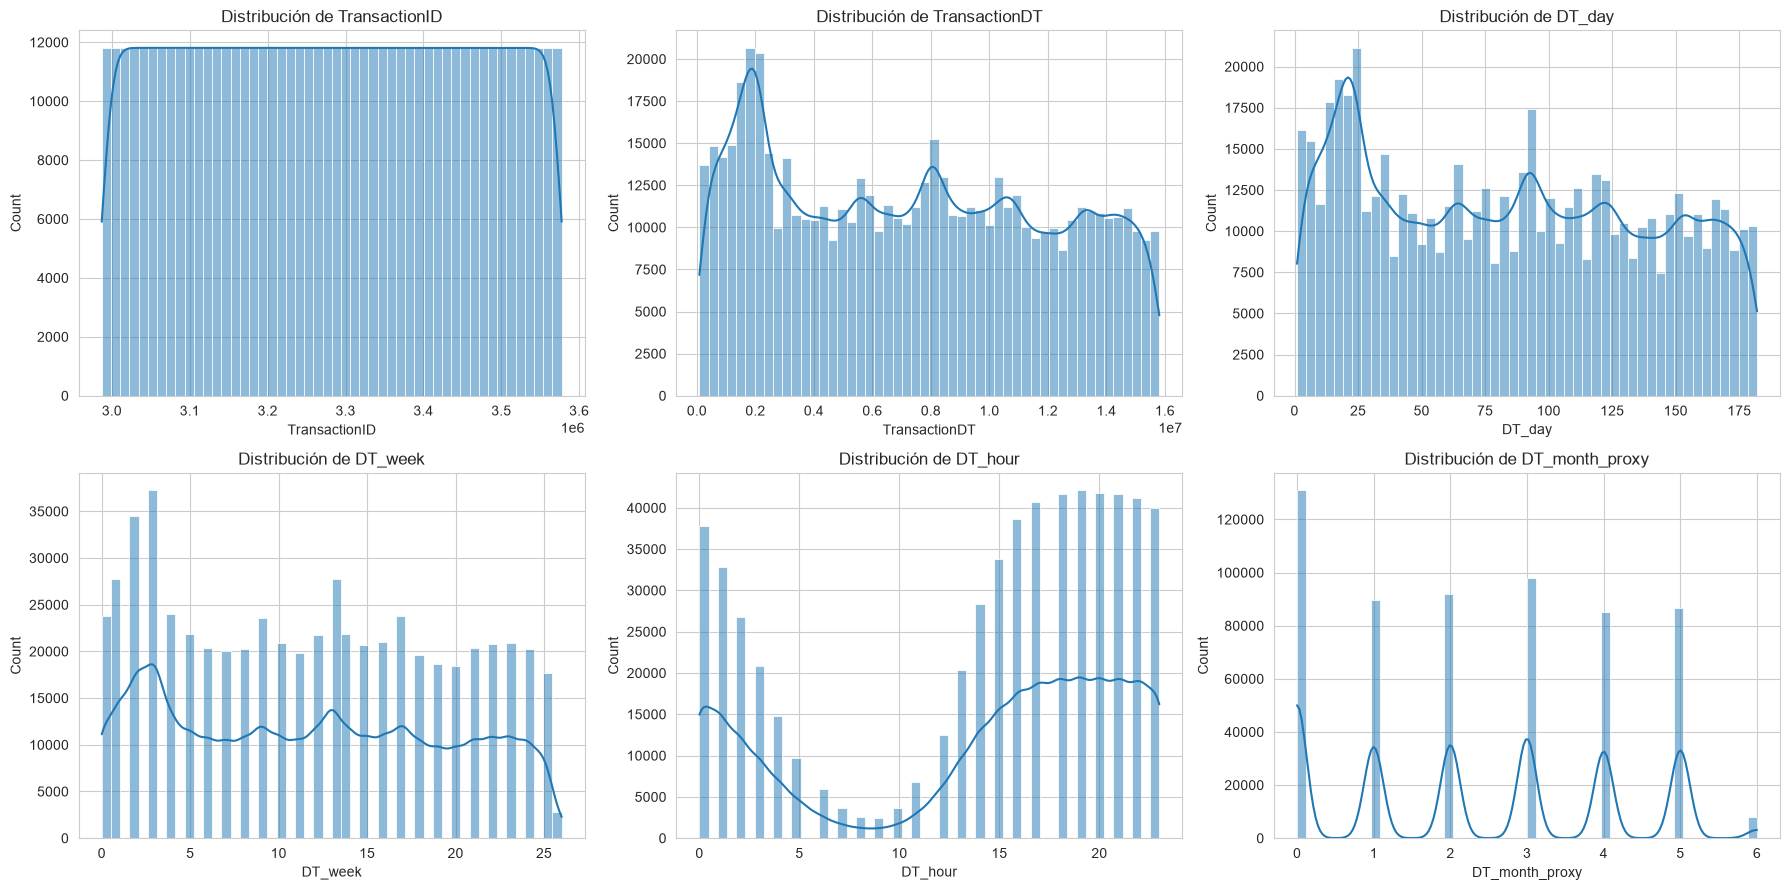

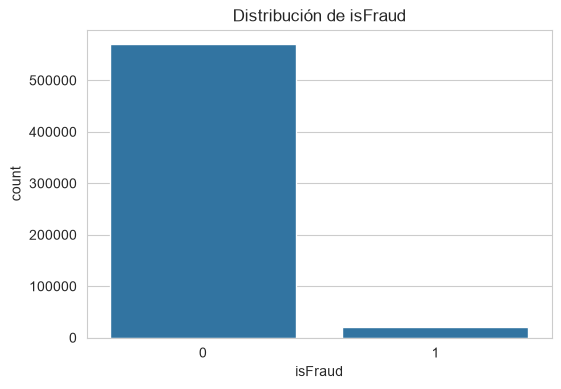

In [66]:
import seaborn as sns

cols = [
    "TransactionID",
    "TransactionDT",
    "DT_day",
    "DT_week",
    "DT_hour",
    "DT_month_proxy",
    "isFraud",
]

df = train[cols].copy()

# Plot distribution of transaction DT

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, col in zip(axes.flat, cols):
    sns.histplot(data=df, x=col, bins=50, kde=True, ax=ax)
    ax.set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="isFraud")
plt.title("Distribución de isFraud")
plt.show()

---

# Fase 1: Familiarización con los datos

Objetivo: catalogar tablas, documentar esquema, evaluar calidad, identificar
cobertura temporal y granularidad.


### 1.1 Resumen estructural


In [ ]:
def structural_summary(train, test):
    rows = []
    for name, df in [("train", train), ("test", test)]:
        identity_cols = [
            c
            for c in df.columns
            if c.startswith("id_") or c in ["DeviceType", "DeviceInfo"]
        ]
        rows.append(
            {
                "dataset": name,
                "rows": len(df),
                "columns": df.shape[1],
                "transaction_id_unique": bool(df["TransactionID"].is_unique),
                "time_days": float(
                    (df["TransactionDT"].max() - df["TransactionDT"].min())
                    / (3600 * 24)
                ),
                "identity_coverage_pct": (
                    float(100 * df[identity_cols[0]].notna().mean())
                    if identity_cols
                    else np.nan
                ),
                "fraud_rate_pct": (
                    float(100 * df["isFraud"].mean()) if name == "train" else np.nan
                ),
            }
        )
    return pd.DataFrame(rows)


structural = structural_summary(train, test)
structural

,dataset,rows,columns,transaction_id_unique,time_days,identity_coverage_pct,fraud_rate_pct
0,train,590540,439,True,181.9992,24.4239,3.4990
1,test,506691,439,True,182.9991,27.0246,NaN


### 1.2 Tipos de datos y categorías de features


In [7]:
# Clasificar columnas por grupo semántico
feature_groups = {
    "target": ["isFraud"],
    "id_key": ["TransactionID"],
    "time": ["TransactionDT", "DT_day", "DT_week", "DT_hour", "DT_month_proxy"],
    "amount": ["TransactionAmt"],
    "product": ["ProductCD"],
    "card": [c for c in train.columns if c.startswith("card")],
    "address": ["addr1", "addr2"],
    "distance": ["dist1", "dist2"],
    "email": ["P_emaildomain", "R_emaildomain"],
    "C_count": [c for c in train.columns if c.startswith("C") and c[1:].isdigit()],
    "D_timedelta": [c for c in train.columns if c.startswith("D") and c[1:].isdigit()],
    "M_match": [c for c in train.columns if c.startswith("M") and c[1:].isdigit()],
    "V_vesta": [c for c in train.columns if c.startswith("V") and c[1:].isdigit()],
    "id_identity": [c for c in train.columns if c.startswith("id_")],
    "device": ["DeviceType", "DeviceInfo"],
}

print("Feature groups:")
for group, cols in feature_groups.items():
    existing = [c for c in cols if c in train.columns]
    print(f"  {group:15s}: {len(existing):3d} columns")

Feature groups:
  target         :   1 columns
  id_key         :   1 columns
  time           :   5 columns
  amount         :   1 columns
  product        :   1 columns
  card           :   6 columns
  address        :   2 columns
  distance       :   2 columns
  email          :   2 columns
  C_count        :  14 columns
  D_timedelta    :  15 columns
  M_match        :   9 columns
  V_vesta        : 339 columns
  id_identity    :  38 columns
  device         :   2 columns


In [8]:
# Dtypes overview
dtype_counts = train.dtypes.value_counts()
print("Dtypes en train:")
print(dtype_counts)

Dtypes en train:
float32    399
str         32
int8         3
int16        3
int32        2
Name: count, dtype: int64


### 1.3 Resumen de valores faltantes


In [ ]:
def missing_summary(train, test):
    rows = []
    for col in train.columns:
        if col in ["dataset", "isFraud"]:
            continue
        rows.append(
            {
                "feature": col,
                "train_missing_pct": 100 * train[col].isna().mean(),
                "test_missing_pct": (
                    100 * test[col].isna().mean() if col in test.columns else np.nan
                ),
                "missing_delta_abs": (
                    abs(100 * train[col].isna().mean() - 100 * test[col].isna().mean())
                    if col in test.columns
                    else np.nan
                ),
                "train_nunique": train[col].nunique(dropna=True),
                "test_nunique": (
                    test[col].nunique(dropna=True) if col in test.columns else np.nan
                ),
                "dtype": str(train[col].dtype),
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["missing_delta_abs", "train_missing_pct"], ascending=False
    )


missing = missing_summary(train, test)

In [ ]:
# Top 30 features con más faltantes en train
print("Top 30 features con más % faltante en train:")
missing.sort_values("train_missing_pct", ascending=False).head(30)[
    [
        "feature",
        "train_missing_pct",
        "test_missing_pct",
        "missing_delta_abs",
        "train_nunique",
    ]
]

Top 30 features con más % faltante en train:


,feature,train_missing_pct,test_missing_pct,missing_delta_abs,train_nunique
416,id_24,99.1962,NaN,NaN,12
417,id_25,99.1310,NaN,NaN,341
399,id_07,99.1271,NaN,NaN,84
400,id_08,99.1271,NaN,NaN,94
413,id_21,99.1264,NaN,NaN,490
418,id_26,99.1257,NaN,NaN,95
419,id_27,99.1247,NaN,NaN,2
414,id_22,99.1247,NaN,NaN,25
415,id_23,99.1247,NaN,NaN,3
13,dist2,93.6284,92.8090,0.8193,1751


In [11]:
# Features con mayor diferencia de faltantes entre train/test
print("Top 20 features con mayor diferencia de faltantes train vs test:")
missing.sort_values("missing_delta_abs", ascending=False).head(20)[
    ["feature", "train_missing_pct", "test_missing_pct", "missing_delta_abs"]
]

Top 20 features con mayor diferencia de faltantes train vs test:


,feature,train_missing_pct,test_missing_pct,missing_delta_abs
42,D13,89.5093,75.6491,13.8602
88,V35,28.6126,15.1678,13.4448
89,V36,28.6126,15.1678,13.4448
90,V37,28.6126,15.1678,13.4448
91,V38,28.6126,15.1678,13.4448
92,V39,28.6126,15.1678,13.4448
93,V40,28.6126,15.1678,13.4448
94,V41,28.6126,15.1678,13.4448
95,V42,28.6126,15.1678,13.4448
96,V43,28.6126,15.1678,13.4448


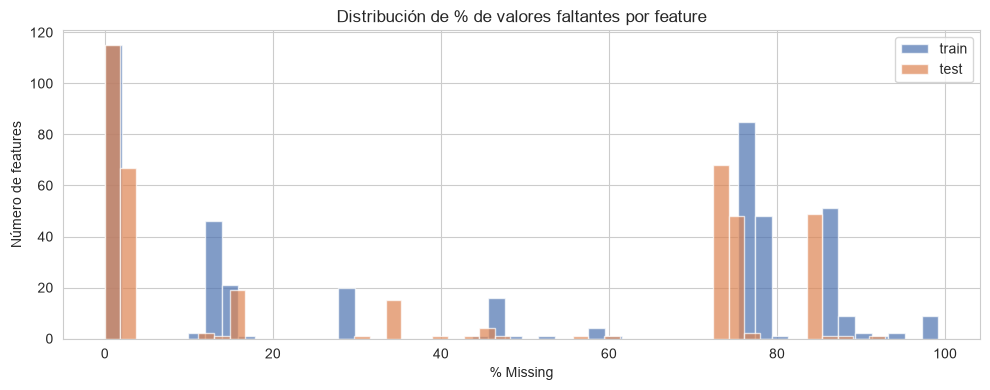

In [ ]:
# Distribución de % faltante
fig, ax = plt.subplots(figsize=(10, 4))
missing["train_missing_pct"].hist(
    bins=50, ax=ax, color="#4C72B0", alpha=0.7, label="train"
)
missing["test_missing_pct"].dropna().hist(
    bins=50, ax=ax, color="#DD8452", alpha=0.7, label="test"
)
ax.set_xlabel("% Missing")
ax.set_ylabel("Número de features")
ax.set_title("Distribución de % de valores faltantes por feature")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Bloques de faltantes: cuántas features tienen >80%, >50%, >20% faltantes
thresholds = [80, 50, 20, 5, 0]
for t in thresholds:
    n = (missing["train_missing_pct"] > t).sum()
    print(f"  Features con >{t}% faltante en train: {n}")

  Features con >80% faltante en train: 74
  Features con >50% faltante en train: 214
  Features con >20% faltante en train: 252
  Features con >5% faltante en train: 322
  Features con >0% faltante en train: 414


### 1.4 Cobertura temporal


In [ ]:
print(
    f"TransactionDT range (train): {train['TransactionDT'].min()} — {train['TransactionDT'].max()}"
)
print(
    f"TransactionDT range (test):  {test['TransactionDT'].min()} — {test['TransactionDT'].max()}"
)
print(
    f"Train days: {train['DT_day'].nunique()} unique days, range {train['DT_day'].min()}-{train['DT_day'].max()}"
)
print(
    f"Test days:  {test['DT_day'].nunique()} unique days, range {test['DT_day'].min()}-{test['DT_day'].max()}"
)
print(f"Train weeks: {train['DT_week'].nunique()}")
print(f"Test weeks:  {test['DT_week'].nunique()}")

TransactionDT range (train): 86400 — 15811131
TransactionDT range (test):  18403224 — 34214345
Train days: 182 unique days, range 1-182
Test days:  183 unique days, range 213-395
Train weeks: 27
Test weeks:  27


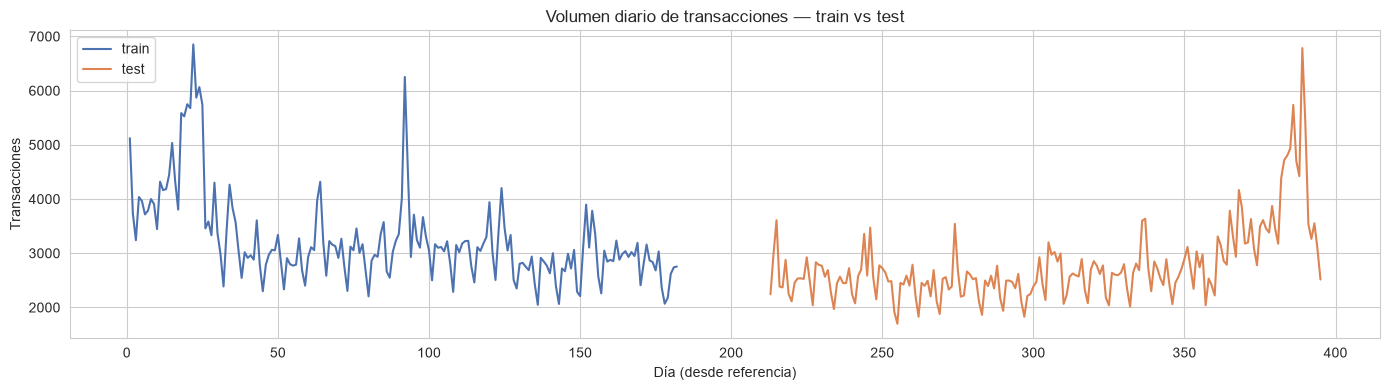

In [15]:
# Volumen diario train vs test
fig, ax = plt.subplots(figsize=(14, 4))
train.groupby("DT_day").size().plot(ax=ax, label="train", color="#4C72B0")
test.groupby("DT_day").size().plot(ax=ax, label="test", color="#DD8452")
ax.set_xlabel("Día (desde referencia)")
ax.set_ylabel("Transacciones")
ax.set_title("Volumen diario de transacciones — train vs test")
ax.legend()
plt.tight_layout()
plt.show()

### 1.5 Distribución del target


Distribución del target isFraud:
          count     pct
isFraud                
0        569877 96.5010
1         20663  3.4990


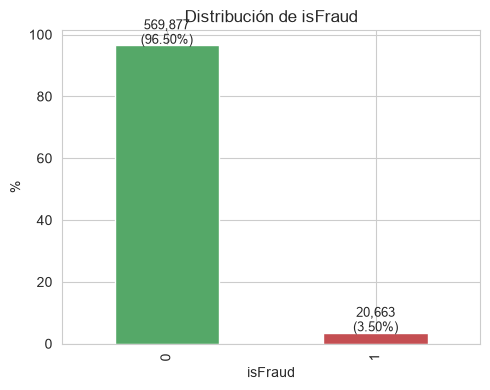

In [16]:
fraud_counts = train["isFraud"].value_counts()
fraud_pct = train["isFraud"].value_counts(normalize=True) * 100
print("Distribución del target isFraud:")
print(pd.DataFrame({"count": fraud_counts, "pct": fraud_pct}))

fig, ax = plt.subplots(figsize=(5, 4))
fraud_pct.sort_index().plot(kind="bar", ax=ax, color=["#55A868", "#C44E52"])
ax.set_title("Distribución de isFraud")
ax.set_xlabel("isFraud")
ax.set_ylabel("%")
for i, (v, p) in enumerate(zip(fraud_counts.sort_index(), fraud_pct.sort_index())):
    ax.text(i, p + 0.5, f"{v:,}\n({p:.2f}%)", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

---

# Fase 2: Descubrimiento de patrones

Exploración sistemática en 3 vectores:

1. Patrones temporales
2. Patrones de segmentación
3. Patrones de relación


## 2.1 Patrones temporales


In [ ]:
def temporal_summary(train):
    rows = []
    for key in ["DT_week", "DT_month_proxy"]:
        g = (
            train.groupby(key, observed=True)
            .agg(
                rows=("TransactionID", "size"),
                fraud_rate=("isFraud", "mean"),
                amt_mean=("TransactionAmt", "mean"),
                amt_median=("TransactionAmt", "median"),
            )
            .reset_index()
            .rename(columns={key: "window"})
        )
        g.insert(0, "window_type", key)
        rows.append(g)
    return pd.concat(rows, ignore_index=True)


temporal = temporal_summary(train)

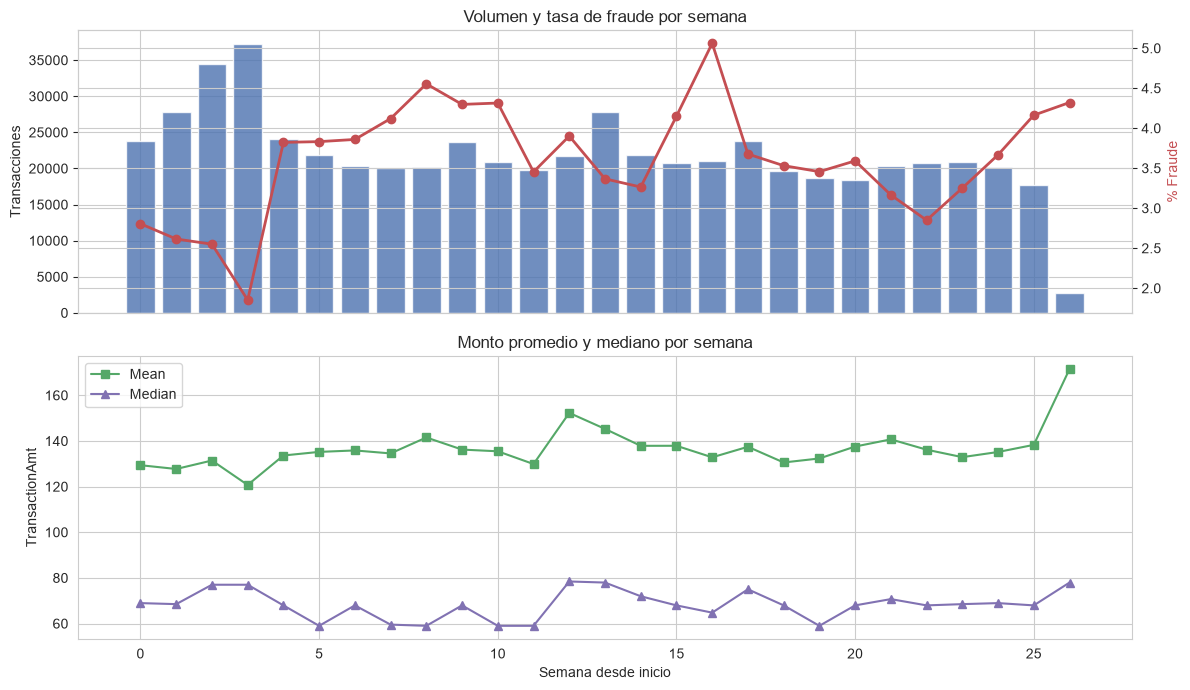

In [ ]:
# Tasa de fraude por semana
weeks = temporal[temporal["window_type"] == "DT_week"]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(weeks["window"], weeks["rows"], color="#4C72B0", alpha=0.8)
axes[0].set_ylabel("Transacciones")
axes[0].set_title("Volumen y tasa de fraude por semana")

ax2 = axes[0].twinx()
ax2.plot(
    weeks["window"], 100 * weeks["fraud_rate"], marker="o", color="#C44E52", linewidth=2
)
ax2.set_ylabel("% Fraude", color="#C44E52")

axes[1].plot(
    weeks["window"], weeks["amt_mean"], marker="s", color="#55A868", label="Mean"
)
axes[1].plot(
    weeks["window"], weeks["amt_median"], marker="^", color="#8172B2", label="Median"
)
axes[1].set_xlabel("Semana desde inicio")
axes[1].set_ylabel("TransactionAmt")
axes[1].set_title("Monto promedio y mediano por semana")
axes[1].legend()

plt.tight_layout()
plt.show()

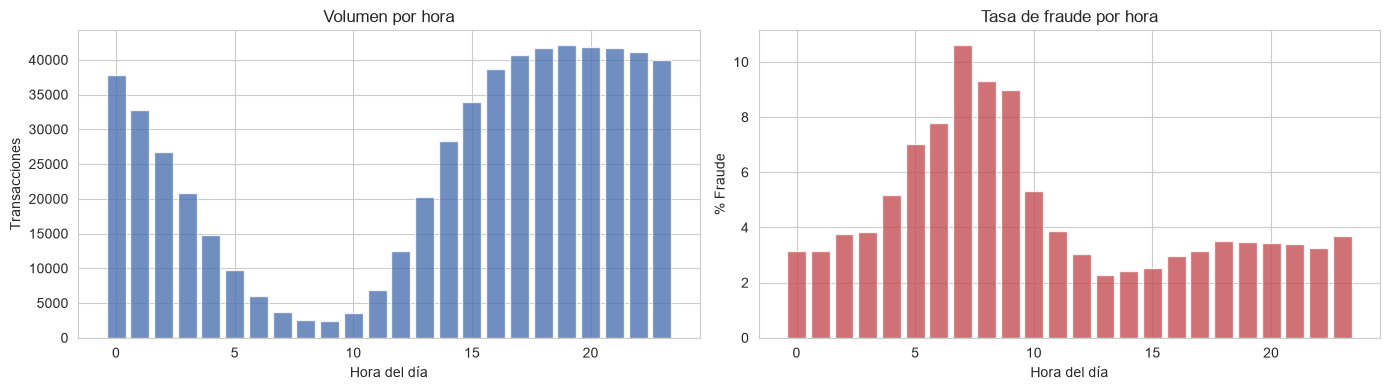

In [ ]:
# Tasa de fraude por hora del día
hourly = (
    train.groupby("DT_hour")
    .agg(
        rows=("TransactionID", "size"),
        fraud_rate=("isFraud", "mean"),
        amt_mean=("TransactionAmt", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(hourly["DT_hour"], hourly["rows"], color="#4C72B0", alpha=0.8)
axes[0].set_xlabel("Hora del día")
axes[0].set_ylabel("Transacciones")
axes[0].set_title("Volumen por hora")

axes[1].bar(hourly["DT_hour"], 100 * hourly["fraud_rate"], color="#C44E52", alpha=0.8)
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("% Fraude")
axes[1].set_title("Tasa de fraude por hora")

plt.tight_layout()
plt.show()

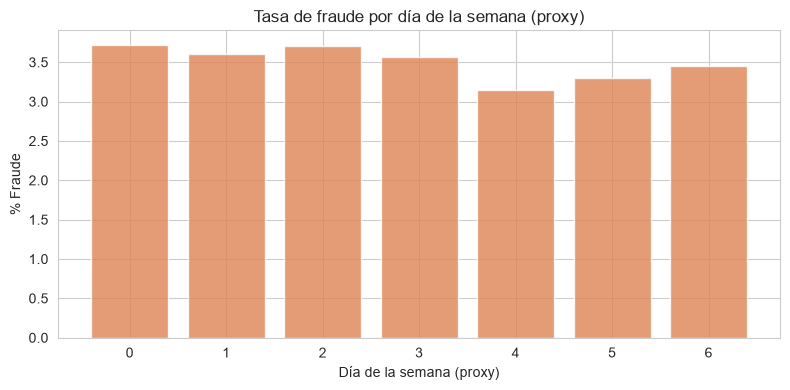

In [ ]:
# Tasa de fraude por día de la semana (proxy: DT_day % 7)
train["DT_dow"] = train["DT_day"] % 7
dow = (
    train.groupby("DT_dow")
    .agg(
        rows=("TransactionID", "size"),
        fraud_rate=("isFraud", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow["DT_dow"], 100 * dow["fraud_rate"], color="#DD8452", alpha=0.8)
ax.set_xlabel("Día de la semana (proxy)")
ax.set_ylabel("% Fraude")
ax.set_title("Tasa de fraude por día de la semana (proxy)")
plt.tight_layout()
plt.show()

## 2.2 Patrones de segmentación


In [ ]:
# Tasa de fraude por categoría
def category_risk(train):
    cat_cols = [
        "ProductCD",
        "card4",
        "card6",
        "P_emaildomain",
        "R_emaildomain",
        "DeviceType",
    ]
    cat_cols += [f"M{i}" for i in range(1, 10) if f"M{i}" in train.columns]
    rows = []
    for col in cat_cols:
        if col not in train.columns:
            continue
        tmp = (
            train.groupby(col, observed=True)["isFraud"]
            .agg(["size", "mean"])
            .reset_index()
        )
        tmp.columns = ["value", "rows", "fraud_rate"]
        tmp["feature"] = col
        tmp["global_fraud_rate"] = train["isFraud"].mean()
        tmp["lift"] = tmp["fraud_rate"] / tmp["global_fraud_rate"]
        rows.append(tmp.sort_values("rows", ascending=False).head(25))
    return pd.concat(rows, ignore_index=True).sort_values(
        ["lift", "rows"], ascending=[False, False]
    )


category = category_risk(train)

Fraud rate by ProductCD:
value   rows  fraud_rate   lift
    C  68519      0.1169 3.3402
    S  11628      0.0590 1.6861
    H  33024      0.0477 1.3622
    R  37699      0.0378 1.0810
    W 439670      0.0204 0.5830


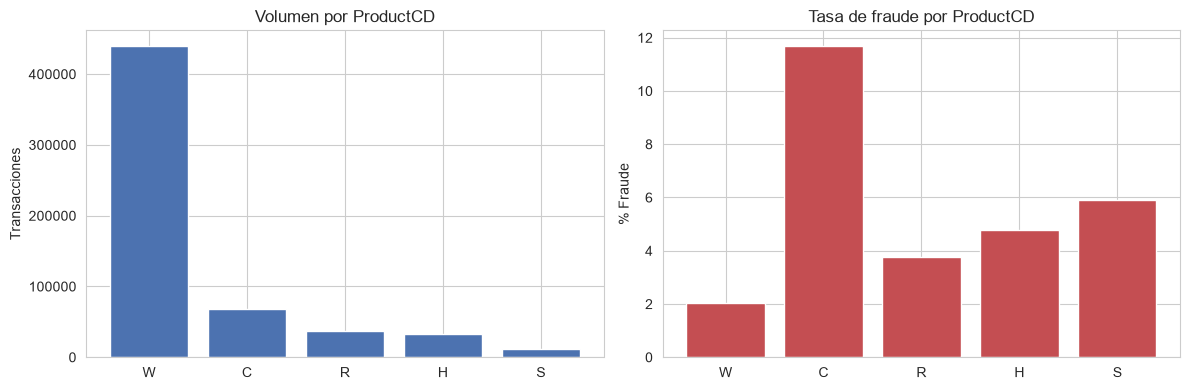

In [ ]:
# ProductCD
prod = category[category["feature"] == "ProductCD"].sort_values(
    "fraud_rate", ascending=False
)
print("Fraud rate by ProductCD:")
print(prod[["value", "rows", "fraud_rate", "lift"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
prod_sorted = prod.sort_values("rows", ascending=False)
axes[0].bar(prod_sorted["value"].astype(str), prod_sorted["rows"], color="#4C72B0")
axes[0].set_title("Volumen por ProductCD")
axes[0].set_ylabel("Transacciones")

axes[1].bar(
    prod_sorted["value"].astype(str), 100 * prod_sorted["fraud_rate"], color="#C44E52"
)
axes[1].set_title("Tasa de fraude por ProductCD")
axes[1].set_ylabel("% Fraude")

plt.tight_layout()
plt.show()


Fraud rate by card4:
           value   rows  fraud_rate   lift
            visa 384767      0.0348 0.9933
      mastercard 189217      0.0343 0.9812
american express   8328      0.0287 0.8202
        discover   6651      0.0773 2.2087

Fraud rate by card6:
          value   rows  fraud_rate   lift
          debit 439938      0.0243 0.6934
         credit 148986      0.0668 1.9087
debit or credit     30      0.0000 0.0000
    charge card     15      0.0000 0.0000


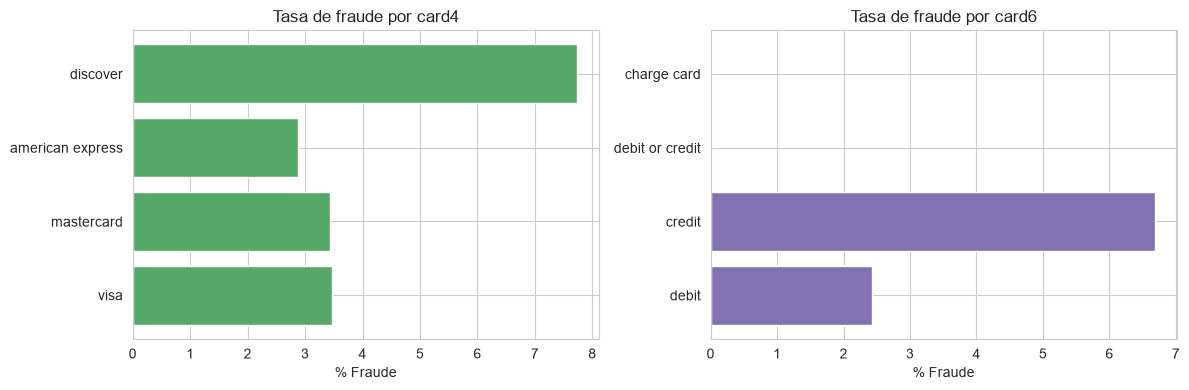

In [23]:
# card4 (red de tarjeta) y card6 (tipo debit/credit)
for feat in ["card4", "card6"]:
    sub = category[category["feature"] == feat].sort_values("rows", ascending=False)
    print(f"\nFraud rate by {feat}:")
    print(sub[["value", "rows", "fraud_rate", "lift"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat, color in zip(axes, ["card4", "card6"], ["#55A868", "#8172B2"]):
    sub = category[category["feature"] == feat].sort_values("rows", ascending=False)
    ax.barh(sub["value"].astype(str), 100 * sub["fraud_rate"], color=color)
    ax.set_xlabel("% Fraude")
    ax.set_title(f"Tasa de fraude por {feat}")
plt.tight_layout()
plt.show()

In [24]:
# DeviceType
sub = category[category["feature"] == "DeviceType"].sort_values("rows", ascending=False)
print("Fraud rate by DeviceType:")
print(sub[["value", "rows", "fraud_rate", "lift"]].to_string(index=False))

Fraud rate by DeviceType:
  value  rows  fraud_rate   lift
desktop 85165      0.0652 1.8638
 mobile 55645      0.1017 2.9055


In [ ]:
# Top email domains por fraude
for feat in ["P_emaildomain", "R_emaildomain"]:
    sub = (
        category[category["feature"] == feat]
        .sort_values("fraud_rate", ascending=False)
        .head(15)
    )
    print(f"\nTop fraud rate by {feat}:")
    print(sub[["value", "rows", "fraud_rate", "lift"]].to_string(index=False))


Top fraud rate by P_emaildomain:
        value   rows  fraud_rate   lift
     mail.com    559      0.1896 5.4194
  outlook.com   5096      0.0946 2.7032
  live.com.mx    749      0.0547 1.5644
  hotmail.com  45250      0.0530 1.5133
    gmail.com 228355      0.0435 1.2444
   icloud.com   6267      0.0314 0.8984
  comcast.net   7888      0.0312 0.8913
  charter.net    816      0.0306 0.8756
bellsouth.net   1909      0.0278 0.7935
     live.com   3041      0.0276 0.7894
anonymous.com  36998      0.0232 0.6635
    yahoo.com 100934      0.0228 0.6504
        gmail    496      0.0222 0.6338
      msn.com   4092      0.0220 0.6286
      aol.com  28289      0.0218 0.6233

Top fraud rate by R_emaildomain:
        value  rows  fraud_rate   lift
  outlook.com  2507      0.1651 4.7196
   outlook.es   433      0.1316 3.7622
   icloud.com  1398      0.1288 3.6798
    gmail.com 57147      0.1192 3.4062
  hotmail.com 27509      0.0778 2.2233
   hotmail.es   292      0.0685 1.9575
  live.com.mx   754

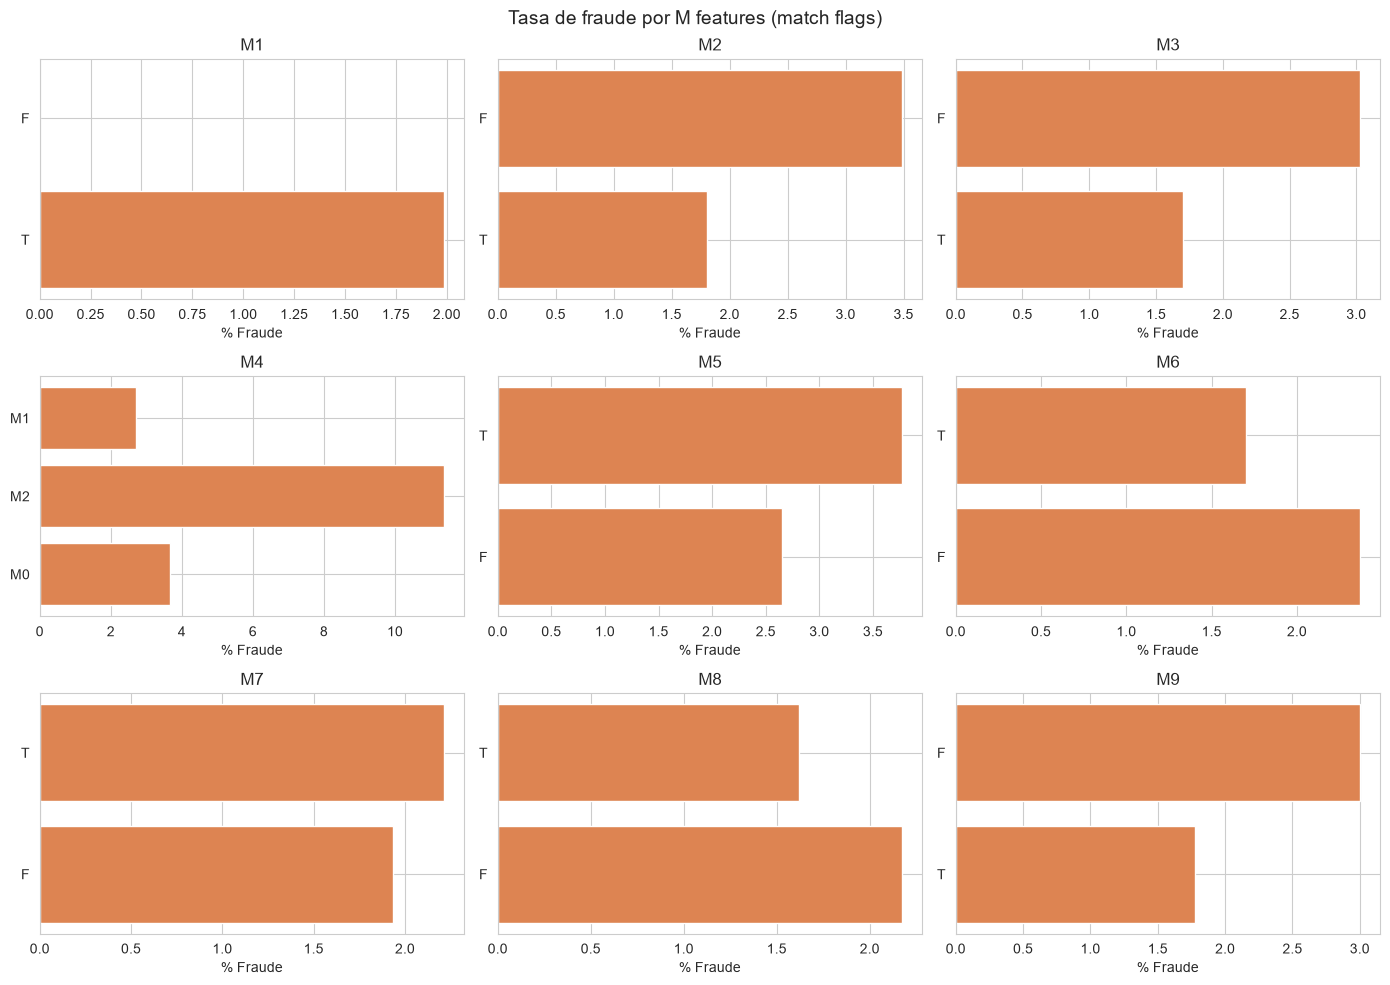

In [ ]:
# M features (match flags)
m_feats = [f for f in category["feature"].unique() if f.startswith("M")]
if m_feats:
    fig, axes = plt.subplots(3, 3, figsize=(14, 10))
    axes = axes.flatten()
    for i, feat in enumerate(sorted(m_feats)):
        sub = category[category["feature"] == feat].sort_values("rows", ascending=False)
        if i < len(axes):
            axes[i].barh(
                sub["value"].astype(str), 100 * sub["fraud_rate"], color="#DD8452"
            )
            axes[i].set_title(feat)
            axes[i].set_xlabel("% Fraude")
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Tasa de fraude por M features (match flags)", fontsize=14)
    plt.tight_layout()
    plt.show()

## 2.3 Patrones de relación


### 2.3.1 Correlaciones con target


In [ ]:
def target_correlations(train):
    num_cols = train.select_dtypes(include=[np.number]).columns.difference(
        ["isFraud", "TransactionID"]
    )
    corrs = train[num_cols].corrwith(train["isFraud"]).dropna()
    out = pd.DataFrame(
        {
            "feature": corrs.index,
            "corr_isFraud": corrs.values,
            "abs_corr": corrs.abs().values,
        }
    ).sort_values("abs_corr", ascending=False)
    return out


corr = target_correlations(train)

In [28]:
# Top 30 features más correlacionadas con isFraud
print("Top 30 features correlacionadas con isFraud:")
corr.head(30)

Top 30 features correlacionadas con isFraud:


,feature,corr_isFraud,abs_corr
211,V257,0.3831,0.3831
199,V246,0.3669,0.3669
197,V244,0.3641,0.3641
195,V242,0.3606,0.3606
150,V201,0.3280,0.3280
149,V200,0.3188,0.3188
135,V189,0.3082,0.3082
134,V188,0.3036,0.3036
212,V258,0.2972,0.2972
315,V45,0.2818,0.2818


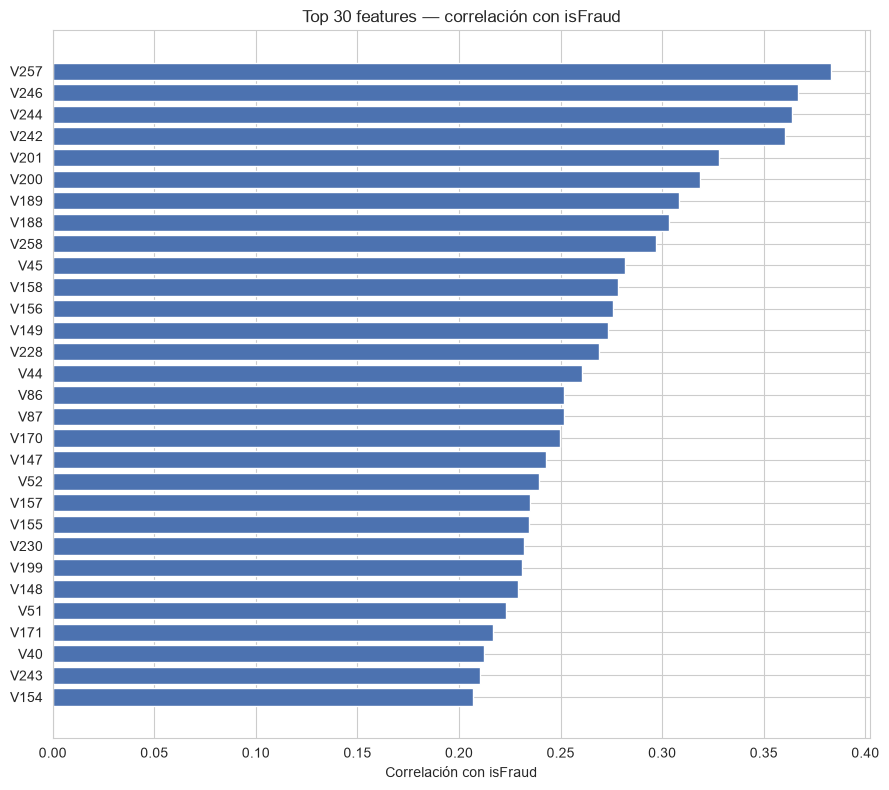

In [29]:
fig, ax = plt.subplots(figsize=(9, 8))
top30 = corr.head(30).sort_values("abs_corr")
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in top30["corr_isFraud"]]
ax.barh(top30["feature"], top30["corr_isFraud"], color=colors)
ax.set_xlabel("Correlación con isFraud")
ax.set_title("Top 30 features — correlación con isFraud")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

### 2.3.2 TransactionAmt — análisis profundo


In [ ]:
def amount_analysis(train):
    amt = train["TransactionAmt"].astype("float64")
    frac = (amt * 100).round(4) % 1
    multi_dec = frac.abs() > 1e-6
    q1, q3 = amt.quantile([0.25, 0.75])
    iqr = q3 - q1
    out_iqr = (amt < q1 - 1.5 * iqr) | (amt > q3 + 1.5 * iqr)
    rows = [
        {
            "transaction_amt_skew": float(stats.skew(amt.dropna())),
            "multi_decimal_pct": float(100 * multi_dec.mean()),
            "multi_decimal_fraud_rate": float(train.loc[multi_dec, "isFraud"].mean()),
            "non_multi_decimal_fraud_rate": float(
                train.loc[~multi_dec, "isFraud"].mean()
            ),
            "iqr_outlier_pct": float(100 * out_iqr.mean()),
            "iqr_outlier_fraud_rate": float(train.loc[out_iqr, "isFraud"].mean()),
            "non_outlier_fraud_rate": float(train.loc[~out_iqr, "isFraud"].mean()),
            "amt_p50": float(amt.quantile(0.50)),
            "amt_p95": float(amt.quantile(0.95)),
            "amt_p99": float(amt.quantile(0.99)),
        }
    ]
    return pd.DataFrame(rows)


amount = amount_analysis(train)
amount.T

,0
transaction_amt_skew,14.3745
multi_decimal_pct,43.6396
multi_decimal_fraud_rate,0.0354
non_multi_decimal_fraud_rate,0.0347
iqr_outlier_pct,11.2578
iqr_outlier_fraud_rate,0.0507
non_outlier_fraud_rate,0.0330
amt_p50,68.7690
amt_p95,445.0000
amt_p99,1104.0000


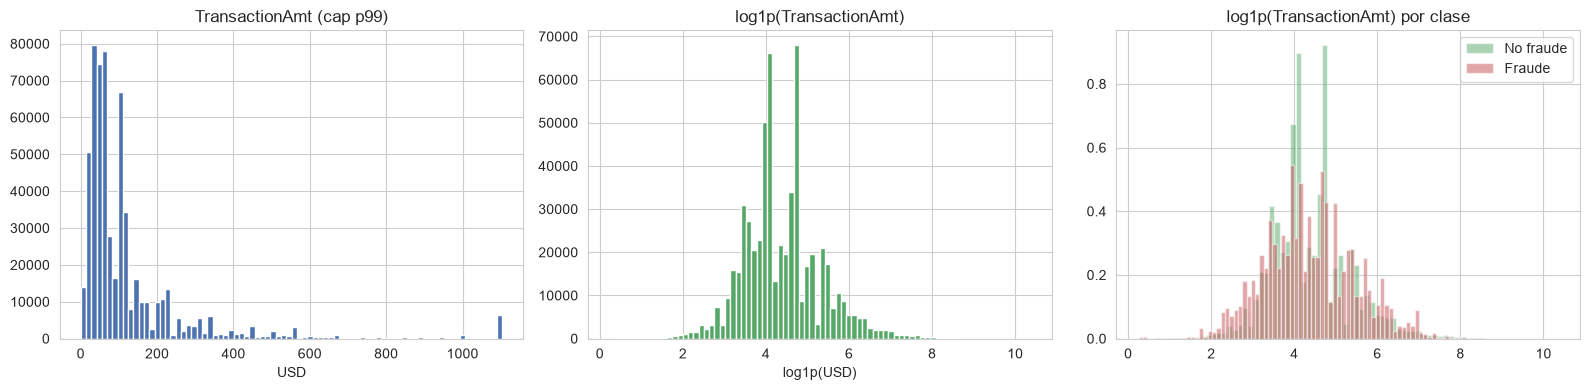

In [ ]:
# Distribución de TransactionAmt
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

train["TransactionAmt"].clip(upper=train["TransactionAmt"].quantile(0.99)).hist(
    bins=80, ax=axes[0], color="#4C72B0"
)
axes[0].set_title("TransactionAmt (cap p99)")
axes[0].set_xlabel("USD")

np.log1p(train["TransactionAmt"]).hist(bins=80, ax=axes[1], color="#55A868")
axes[1].set_title("log1p(TransactionAmt)")
axes[1].set_xlabel("log1p(USD)")

# Fraude vs no-fraude
for label, color, val in [(0, "#55A868", "No fraude"), (1, "#C44E52", "Fraude")]:
    sub = train[train["isFraud"] == label]["TransactionAmt"]
    np.log1p(sub).hist(
        bins=80, ax=axes[2], color=color, alpha=0.5, label=val, density=True
    )
axes[2].set_title("log1p(TransactionAmt) por clase")
axes[2].legend()

plt.tight_layout()
plt.show()

### 2.3.3 Distribution shift train vs test (KS)


In [ ]:
def numeric_distribution_shift(train, test, sample_n=250000):
    numeric = train.select_dtypes(include=[np.number]).columns.intersection(
        test.select_dtypes(include=[np.number]).columns
    )
    numeric = [c for c in numeric if c not in ["isFraud", "TransactionID"]]
    rng = np.random.default_rng(42)
    rows = []
    for col in numeric:
        a = train[col].dropna()
        b = test[col].dropna()
        if len(a) < 100 or len(b) < 100:
            continue
        if len(a) > sample_n:
            a = a.iloc[rng.choice(len(a), sample_n, replace=False)]
        if len(b) > sample_n:
            b = b.iloc[rng.choice(len(b), sample_n, replace=False)]
        try:
            ks = stats.ks_2samp(a.astype("float64"), b.astype("float64")).statistic
        except Exception:
            ks = np.nan
        rows.append(
            {
                "feature": col,
                "ks_train_test": ks,
                "train_mean": float(a.mean()),
                "test_mean": float(b.mean()),
                "mean_delta": float(b.mean() - a.mean()),
                "train_missing_pct": 100 * train[col].isna().mean(),
                "test_missing_pct": 100 * test[col].isna().mean(),
            }
        )
    return pd.DataFrame(rows).sort_values("ks_train_test", ascending=False)


shift = numeric_distribution_shift(train, test)

In [33]:
# Top 30 features con mayor KS statistic
print("Top 30 features con mayor distribution shift (KS) train vs test:")
shift.head(30)

Top 30 features con mayor distribution shift (KS) train vs test:


,feature,ks_train_test,train_mean,test_mean,mean_delta,train_missing_pct,test_missing_pct
381,DT_month_proxy,1.0000,2.3496,9.8914,7.5418,0.0000,0.0000
0,TransactionDT,1.0000,7369693.2904,26928421.4440,19558728.1536,0.0000,0.0000
379,DT_week,1.0000,11.6989,44.0158,32.3168,0.0000,0.0000
378,DT_day,1.0000,84.6820,311.1250,226.4430,0.0000,0.0000
97,V59,0.1264,0.1345,0.2669,0.1324,13.0552,2.5457
98,V60,0.1252,0.1426,0.2794,0.1368,13.0552,2.5457
56,V18,0.1244,0.1352,0.2614,0.1262,12.8819,2.4846
55,V17,0.1235,0.1337,0.2595,0.1258,12.8819,2.4846
102,V64,0.1230,0.1413,0.2800,0.1387,13.0552,2.5457
101,V63,0.1225,0.1304,0.2570,0.1265,13.0552,2.5457


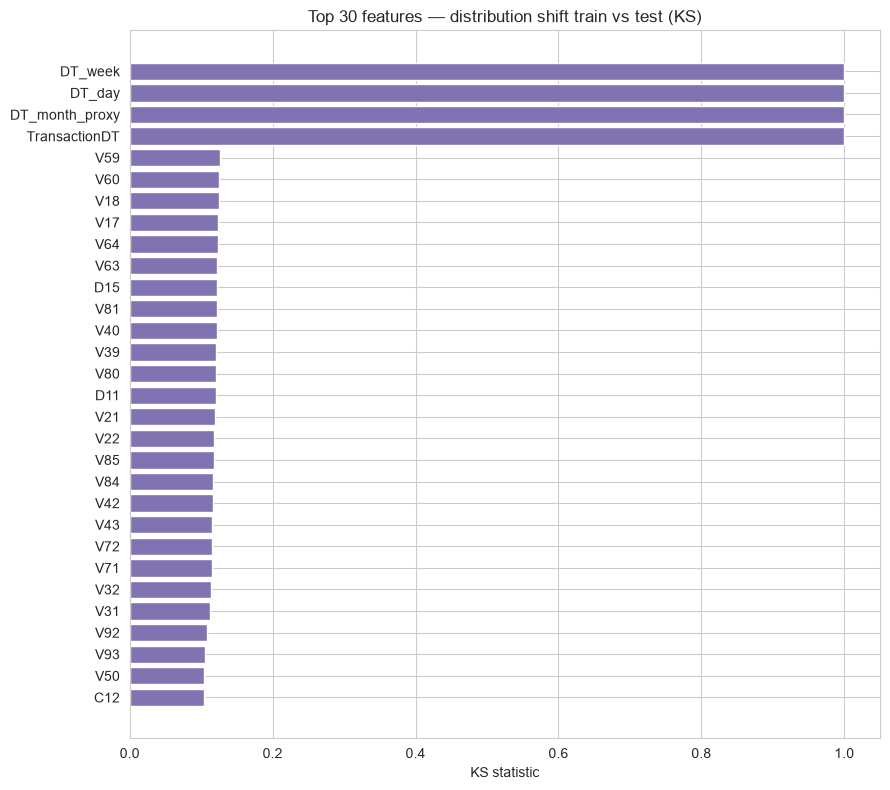

In [34]:
fig, ax = plt.subplots(figsize=(9, 8))
top_shift = shift.head(30).sort_values("ks_train_test")
ax.barh(top_shift["feature"], top_shift["ks_train_test"], color="#8172B2")
ax.set_xlabel("KS statistic")
ax.set_title("Top 30 features — distribution shift train vs test (KS)")
plt.tight_layout()
plt.show()

### 2.3.4 Redundancia entre features V/C/D


In [ ]:
def redundancy_summary(train):
    rows = []
    for prefix in ["C", "D", "V"]:
        cols = [c for c in train.columns if c.startswith(prefix) and c[1:].isdigit()]
        cols = [c for c in cols if pd.api.types.is_numeric_dtype(train[c])]
        if len(cols) < 2:
            continue
        sample = train[cols].sample(min(len(train), 120000), random_state=42)
        corr_mat = sample.corr().abs()
        upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
        pairs = upper.stack().reset_index()
        pairs.columns = ["feature_a", "feature_b", "abs_corr"]
        top = pairs.sort_values("abs_corr", ascending=False).head(50)
        top.insert(0, "group", prefix)
        rows.append(top)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


redundancy = redundancy_summary(train)

In [36]:
# Pares más correlacionados por grupo
print("Top pares redundantes (|corr| > 0.95):")
high_red = redundancy[redundancy["abs_corr"] > 0.95]
print(f"  Pares con |corr| > 0.95: {len(high_red)}")
for group in ["C", "D", "V"]:
    n = len(high_red[high_red["group"] == group])
    print(f"    Grupo {group}: {n} pares")

print("\nTop 20 pares más correlacionados:")
redundancy.head(20)

Top pares redundantes (|corr| > 0.95):
  Pares con |corr| > 0.95: 81
    Grupo C: 26 pares
    Grupo D: 5 pares
    Grupo V: 50 pares

Top 20 pares más correlacionados:


,group,feature_a,feature_b,abs_corr
0,C,C7,C12,0.9994
1,C,C8,C10,0.9968
2,C,C1,C11,0.9962
3,C,C1,C2,0.9945
4,C,C2,C11,0.9932
5,C,C6,C11,0.9908
6,C,C7,C10,0.9842
7,C,C6,C14,0.9838
8,C,C10,C12,0.9829
9,C,C8,C12,0.9821


### 2.3.5 Análisis de UID candidato y leakage temporal


In [ ]:
def uid_overlap_analysis(train):
    train = train.copy()
    train["candidate_uid"] = candidate_uid(train)
    cutoff = train["TransactionDT"].quantile(0.80)
    train["split"] = np.where(
        train["TransactionDT"] <= cutoff, "train_early", "valid_late"
    )
    uid_sides = train.groupby("candidate_uid")["split"].nunique()
    crossing_uids = set(uid_sides[uid_sides > 1].index)
    train["uid_crosses_temporal_cut"] = train["candidate_uid"].isin(crossing_uids)

    late = train[train["split"] == "valid_late"]
    known_late = late["candidate_uid"].isin(
        set(train.loc[train["split"] == "train_early", "candidate_uid"])
    )
    rows = [
        {
            "cutoff_quantile": 0.80,
            "cutoff_transactiondt": float(cutoff),
            "candidate_uid_count": int(train["candidate_uid"].nunique()),
            "crossing_uid_count": int(len(crossing_uids)),
            "all_rows_in_crossing_uid_pct": float(
                100 * train["uid_crosses_temporal_cut"].mean()
            ),
            "late_rows_known_uid_pct": float(100 * known_late.mean()),
            "late_known_uid_fraud_rate": float(late.loc[known_late, "isFraud"].mean()),
            "late_unknown_uid_fraud_rate": float(
                late.loc[~known_late, "isFraud"].mean()
            ),
            "late_known_rows": int(known_late.sum()),
            "late_unknown_rows": int((~known_late).sum()),
        }
    ]
    return pd.DataFrame(rows)


uid = uid_overlap_analysis(train)
uid.T

,0
cutoff_quantile,0.8000
cutoff_transactiondt,12192853.6000
candidate_uid_count,222477.0000
crossing_uid_count,21375.0000
all_rows_in_crossing_uid_pct,30.1167
late_rows_known_uid_pct,42.7642
late_known_uid_fraud_rate,0.0201
late_unknown_uid_fraud_rate,0.0451
late_known_rows,50508.0000
late_unknown_rows,67600.0000


---

# Fase 3: Investigación de anomalías

Identificar 3-5 anomalías específicas de las fases anteriores,
investigar cada una y determinar si son problemas de calidad o fenómenos reales.


### 3.1 Anomalía: TransactionAmt con decimales multi-nivel


In [ ]:
amt = train["TransactionAmt"].astype("float64")
frac = (amt * 100).round(4) % 1
multi_dec = frac.abs() > 1e-6

print(
    f"Transacciones con decimales más allá de centavos: {multi_dec.sum():,} ({100*multi_dec.mean():.2f}%)"
)
print(f"  Fraud rate (multi-decimal): {train.loc[multi_dec, 'isFraud'].mean():.4f}")
print(f"  Fraud rate (standard):      {train.loc[~multi_dec, 'isFraud'].mean():.4f}")

# Posible causa: conversión de moneda extranjera
print(
    f"\n  Amt stats (multi-dec):  mean={amt[multi_dec].mean():.2f}, median={amt[multi_dec].median():.2f}"
)
print(
    f"  Amt stats (standard):  mean={amt[~multi_dec].mean():.2f}, median={amt[~multi_dec].median():.2f}"
)

# Distribución por ProductCD
print("\n  Multi-decimal by ProductCD:")
cross = pd.crosstab(train["ProductCD"], multi_dec, normalize="index") * 100
cross.columns = ["standard_pct", "multi_dec_pct"]
print(cross)

Transacciones con decimales más allá de centavos: 257,709 (43.64%)
  Fraud rate (multi-decimal): 0.0354
  Fraud rate (standard):      0.0347

  Amt stats (multi-dec):  mean=137.78, median=57.95
  Amt stats (standard):  mean=132.90, median=87.00

  Multi-decimal by ProductCD:
           standard_pct  multi_dec_pct
ProductCD                             
C                4.7388        95.2612
H              100.0000         0.0000
R              100.0000         0.0000
S               99.8882         0.1118
W               56.2344        43.7656


### 3.2 Anomalía: Features con >80% faltante — ¿bloque de identity?


In [ ]:
high_missing = missing[missing["train_missing_pct"] > 80].sort_values(
    "train_missing_pct", ascending=False
)
print(f"Features con >80% faltante en train: {len(high_missing)}")

# ¿Son todas del grupo identity?
id_cols = set(
    c for c in train.columns if c.startswith("id_") or c in ["DeviceType", "DeviceInfo"]
)
high_missing_names = set(high_missing["feature"])
from_identity = high_missing_names & id_cols
from_other = high_missing_names - id_cols

print(f"  De identity: {len(from_identity)}")
print(f"  De transaction: {len(from_other)}")
if from_other:
    print(f"  Transaction features >80% missing: {sorted(from_other)}")

# ¿El patrón de faltantes es igual en train/test?
print(
    f"\n  Max missing_delta_abs para features >80% missing: {high_missing['missing_delta_abs'].max():.2f}%"
)

Features con >80% faltante en train: 74
  De identity: 19
  De transaction: 55
  Transaction features >80% missing: ['D12', 'D13', 'D14', 'D6', 'D7', 'D8', 'D9', 'V138', 'V139', 'V140', 'V141', 'V142', 'V143', 'V144', 'V145', 'V146', 'V147', 'V148', 'V149', 'V150', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V159', 'V160', 'V161', 'V162', 'V163', 'V164', 'V165', 'V166', 'V322', 'V323', 'V324', 'V325', 'V326', 'V327', 'V328', 'V329', 'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338', 'V339', 'dist2']

  Max missing_delta_abs para features >80% missing: 13.86%


### 3.3 Anomalía: Distribution shift extremo en features específicas


In [ ]:
extreme_shift = shift[shift["ks_train_test"] > 0.20]
print(f"Features con KS > 0.20 (distribution shift severo): {len(extreme_shift)}")
print(
    extreme_shift[
        ["feature", "ks_train_test", "train_mean", "test_mean", "mean_delta"]
    ].head(15)
)

# Verificar si son temporales
temporal_features = ["DT_day", "DT_week", "DT_month_proxy", "TransactionDT"]
temp_shift = extreme_shift[extreme_shift["feature"].isin(temporal_features)]
non_temp_shift = extreme_shift[~extreme_shift["feature"].isin(temporal_features)]
print(f"\n  Temporal features con alto shift: {len(temp_shift)}")
print(f"  Non-temporal features con alto shift: {len(non_temp_shift)}")
if len(non_temp_shift):
    print("  Non-temporal high-shift features:")
    print(
        non_temp_shift[["feature", "ks_train_test", "mean_delta"]].to_string(
            index=False
        )
    )

Features con KS > 0.20 (distribution shift severo): 4
            feature  ks_train_test   train_mean     test_mean    mean_delta
381  DT_month_proxy         1.0000       2.3496        9.8914        7.5418
0     TransactionDT         1.0000 7369693.2904 26928421.4440 19558728.1536
379         DT_week         1.0000      11.6989       44.0158       32.3168
378          DT_day         1.0000      84.6820      311.1250      226.4430

  Temporal features con alto shift: 4
  Non-temporal features con alto shift: 0


### 3.4 Anomalía: Variación semanal de tasa de fraude


In [ ]:
weeks = temporal[temporal["window_type"] == "DT_week"]
fraud_min = 100 * weeks["fraud_rate"].min()
fraud_max = 100 * weeks["fraud_rate"].max()
fraud_std = 100 * weeks["fraud_rate"].std()
print(
    f"Tasa de fraude semanal: min={fraud_min:.2f}%, max={fraud_max:.2f}%, std={fraud_std:.2f}%"
)
print(f"Ratio max/min: {fraud_max/fraud_min:.2f}x")

# Semanas con tasa anómala (>2 std del promedio)
fraud_mean = weeks["fraud_rate"].mean()
fraud_2std = fraud_mean + 2 * weeks["fraud_rate"].std()
anomalous_weeks = weeks[weeks["fraud_rate"] > fraud_2std]
print(f"\nSemanas con tasa >2σ del promedio ({100*fraud_2std:.2f}%):")
if len(anomalous_weeks):
    print(anomalous_weeks[["window", "rows", "fraud_rate"]].to_string(index=False))
else:
    print("  Ninguna")

Tasa de fraude semanal: min=1.85%, max=5.06%, std=0.70%
Ratio max/min: 2.73x

Semanas con tasa >2σ del promedio (5.00%):
 window  rows  fraud_rate
     16 21003      0.0506


### 3.5 Anomalía: UID conocido vs desconocido — diferencia de fraud rate


In [ ]:
print("Análisis UID — segmento late (validación temporal):")
print(uid.T.to_string())
print(f"\nDiferencia de fraud rate known vs unknown UID:")
diff = (
    uid["late_known_uid_fraud_rate"].iloc[0]
    - uid["late_unknown_uid_fraud_rate"].iloc[0]
)
print(
    f"  {uid['late_known_uid_fraud_rate'].iloc[0]:.4f} vs {uid['late_unknown_uid_fraud_rate'].iloc[0]:.4f} = delta {diff:.4f}"
)
print(
    f"  Esto indica {'posible leakage' if abs(diff) > 0.01 else 'diferencia menor'} al usar UID features en validación."
)

Análisis UID — segmento late (validación temporal):
                                         0
cutoff_quantile                     0.8000
cutoff_transactiondt         12192853.6000
candidate_uid_count            222477.0000
crossing_uid_count              21375.0000
all_rows_in_crossing_uid_pct       30.1167
late_rows_known_uid_pct            42.7642
late_known_uid_fraud_rate           0.0201
late_unknown_uid_fraud_rate         0.0451
late_known_rows                 50508.0000
late_unknown_rows               67600.0000

Diferencia de fraud rate known vs unknown UID:
  0.0201 vs 0.0451 = delta -0.0251
  Esto indica posible leakage al usar UID features en validación.


---

# Fase 4: Generación de insights

Criterios: cada insight debe ser **accionable**, **sorprendente** o **significativo**.


### Insight 1: Desbalance extremo del target requiere métricas especiales


In [ ]:
fraud_rate = structural.loc[structural["dataset"] == "train", "fraud_rate_pct"].iloc[0]
print(f"Fraud rate: {fraud_rate:.2f}%")
print("→ Accuracy sería engañosa (un clasificador dummy logra ~96.5%).")
print(
    "→ Usar PR-AUC como métrica principal. Complementar con recall, precision, F1, ROC-AUC."
)

Fraud rate: 3.50%
→ Accuracy sería engañosa (un clasificador dummy logra ~96.5%).
→ Usar PR-AUC como métrica principal. Complementar con recall, precision, F1, ROC-AUC.


### Insight 2: TransactionAmt con decimales multi-nivel es señal de fraude


In [ ]:
print(f"Multi-decimal fraud rate:     {amount['multi_decimal_fraud_rate'].iloc[0]:.4f}")
print(
    f"Non-multi-decimal fraud rate: {amount['non_multi_decimal_fraud_rate'].iloc[0]:.4f}"
)
lift_dec = (
    amount["multi_decimal_fraud_rate"].iloc[0]
    / amount["non_multi_decimal_fraud_rate"].iloc[0]
)
print(f"Lift: {lift_dec:.2f}x")
print(
    "→ Montos con decimales extraños (conversión de moneda) correlacionan con fraude."
)
print("→ Feature: is_multi_decimal flag.")

Multi-decimal fraud rate:     0.0354
Non-multi-decimal fraud rate: 0.0347
Lift: 1.02x
→ Montos con decimales extraños (conversión de moneda) correlacionan con fraude.
→ Feature: is_multi_decimal flag.


### Insight 3: Distribution shift temporal significativo limita generalización


In [45]:
n_high_shift = (shift["ks_train_test"] > 0.20).sum()
print(f"Features con KS > 0.20: {n_high_shift}")
print("→ Features temporales y derivadas del tiempo dominan el shift.")
print("→ Necesario: adversarial validation, PSI monitoring, temporal cross-validation.")

Features con KS > 0.20: 4
→ Features temporales y derivadas del tiempo dominan el shift.
→ Necesario: adversarial validation, PSI monitoring, temporal cross-validation.


### Insight 4: UIDs candidatos cruzan corte temporal — riesgo de leakage


In [ ]:
print(
    f"% filas en UIDs que cruzan corte temporal: {uid['all_rows_in_crossing_uid_pct'].iloc[0]:.2f}%"
)
print(
    f"% filas tardías con UID conocido: {uid['late_rows_known_uid_pct'].iloc[0]:.2f}%"
)
print("→ Muchos 'usuarios' aparecen en ambos lados del split temporal.")
print("→ Features UID son poderosas pero deben calcularse sin información futura.")
print("→ Reportar desempeño separado: UID conocido vs desconocido.")

% filas en UIDs que cruzan corte temporal: 30.12%
% filas tardías con UID conocido: 42.76%
→ Muchos 'usuarios' aparecen en ambos lados del split temporal.
→ Features UID son poderosas pero deben calcularse sin información futura.
→ Reportar desempeño separado: UID conocido vs desconocido.


### Insight 5: Bloques de V-features son altamente redundantes


In [47]:
high_red_v = redundancy[(redundancy["group"] == "V") & (redundancy["abs_corr"] > 0.95)]
print(f"Pares V con |corr| > 0.95: {len(high_red_v)}")
print("→ Reducción agresiva de V features necesaria.")
print("→ Estrategia: PCA por bloque o selección por permutation importance.")

Pares V con |corr| > 0.95: 50
→ Reducción agresiva de V features necesaria.
→ Estrategia: PCA por bloque o selección por permutation importance.


---

# Fase 5: Formulación de preguntas

Preguntas específicas y accionables para investigación más profunda.


### Adversarial validation train vs test


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split


def adversarial_validation(train, test):
    feature_candidates = [
        "TransactionAmt",
        "DT_day",
        "DT_hour",
        "DT_month_proxy",
        "card1",
        "card2",
        "card3",
        "card5",
        "addr1",
        "addr2",
        "dist1",
        "dist2",
        "C1",
        "C2",
        "C5",
        "C13",
        "D1",
        "D2",
        "D10",
        "D15",
    ]
    feature_candidates += [
        f"V{i}" for i in [1, 3, 4, 12, 34, 53, 62, 70, 95, 127, 170, 201, 258, 307]
    ]
    feature_candidates = [
        c for c in feature_candidates if c in train.columns and c in test.columns
    ]

    base_cols = list(
        dict.fromkeys(feature_candidates + ["TransactionID", "TransactionDT"])
    )
    tr = add_time_features(train[base_cols].copy())
    te = add_time_features(test[base_cols].copy())
    tr["target_is_test"] = 0
    te["target_is_test"] = 1
    both = pd.concat([tr, te], ignore_index=True)
    y = both.pop("target_is_test").astype("int8")
    both = both.drop(columns=["TransactionID"], errors="ignore")

    for col in both.columns:
        if not pd.api.types.is_numeric_dtype(both[col]):
            codes, _ = pd.factorize(both[col].astype("string"), sort=True)
            both[col] = codes
        both[col] = both[col].astype("float32")
        both[col] = both[col].fillna(-999)

    if len(both) > 300000:
        idx = both.sample(300000, random_state=42).index
        X = both.loc[idx]
        yy = y.loc[idx]
    else:
        X = both
        yy = y

    X_train, X_val, y_train, y_val = train_test_split(
        X, yy, test_size=0.30, random_state=42, stratify=yy
    )
    model = HistGradientBoostingClassifier(
        max_iter=80, learning_rate=0.08, max_leaf_nodes=31, random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, pred)
    ap = average_precision_score(y_val, pred)

    # Permutation importance on validation
    base_auc = auc
    rng = np.random.default_rng(42)
    imps = []
    for col in X_val.columns:
        Xp = X_val.copy()
        Xp[col] = rng.permutation(Xp[col].to_numpy())
        auc_p = roc_auc_score(y_val, model.predict_proba(Xp)[:, 1])
        imps.append({"feature": col, "adversarial_auc_drop": base_auc - auc_p})
    imp = pd.DataFrame(imps).sort_values("adversarial_auc_drop", ascending=False)
    metrics = pd.DataFrame(
        [
            {
                "adversarial_roc_auc": auc,
                "adversarial_pr_auc": ap,
                "features_used": len(feature_candidates),
            }
        ]
    )
    return metrics, imp


print("Running adversarial validation...")
adv_metrics, adv_importance = adversarial_validation(train, test)

Running adversarial validation...


In [49]:
print("Adversarial validation metrics:")
print(adv_metrics.to_string(index=False))

print("\nTop 15 features que más distinguen train de test:")
print(adv_importance.head(15).to_string(index=False))

Adversarial validation metrics:
 adversarial_roc_auc  adversarial_pr_auc  features_used
              1.0000              1.0000             34

Top 15 features que más distinguen train de test:
       feature  adversarial_auc_drop
        DT_day                0.5007
TransactionAmt                0.0000
       DT_hour                0.0000
DT_month_proxy                0.0000
         card1                0.0000
         card2                0.0000
         card3                0.0000
         card5                0.0000
         addr1                0.0000
         addr2                0.0000
         dist1                0.0000
         dist2                0.0000
            C1                0.0000
            C2                0.0000
            C5                0.0000


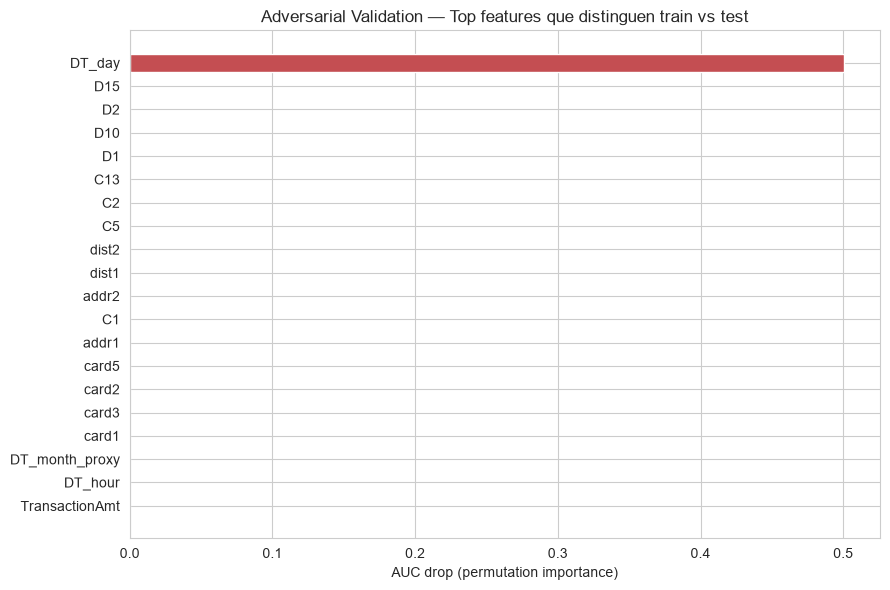

In [50]:
fig, ax = plt.subplots(figsize=(9, 6))
top_imp = adv_importance.head(20).sort_values("adversarial_auc_drop")
ax.barh(top_imp["feature"], top_imp["adversarial_auc_drop"], color="#C44E52")
ax.set_xlabel("AUC drop (permutation importance)")
ax.set_title("Adversarial Validation — Top features que distinguen train vs test")
plt.tight_layout()
plt.show()

---

## Decision log — Resumen de decisiones de modelado


In [ ]:
def make_decision_log(
    structural, missing, corr, temporal, uid, amount, shift, adv_metrics
):
    fraud_rate = structural.loc[
        structural["dataset"] == "train", "fraud_rate_pct"
    ].iloc[0]
    weekly = temporal[temporal["window_type"] == "DT_week"]
    min_week = 100 * weekly["fraud_rate"].min()
    max_week = 100 * weekly["fraud_rate"].max()
    known_late = uid["late_rows_known_uid_pct"].iloc[0]
    adv_auc = adv_metrics["adversarial_roc_auc"].iloc[0]
    high_missing = int((missing["train_missing_pct"] > 80).sum())
    high_shift = int((shift["ks_train_test"] > 0.20).sum())
    max_corr = corr["abs_corr"].max()

    rows = [
        {
            "decision": "Usar PR-AUC como métrica principal",
            "evidence": f"Fraude en train = {fraud_rate:.2f}%; accuracy sería engañosa.",
            "modeling_impact": "Reportar PR-AUC, recall, precision, F1 y FPR por ventana temporal.",
        },
        {
            "decision": "No usar TransactionDT crudo como feature",
            "evidence": "Es la variable que define el orden temporal; usarla cruda puede aprender posición histórica.",
            "modeling_impact": "Derivar hora/día/semana y usar TransactionDT para split y monitoreo.",
        },
        {
            "decision": "Separar validación temporal en UID conocido y UID desconocido",
            "evidence": f"{known_late:.2f}% de filas tardías comparten candidate_uid con entrenamiento temprano.",
            "modeling_impact": "Reportar desempeño por segmento y evitar conclusiones infladas.",
        },
        {
            "decision": "Crear features UID, pero sin usar información futura",
            "evidence": "card/D/addr forman clientes candidatos repetidos; top soluciones IEEE explotan esa señal.",
            "modeling_impact": "Frequency/agregaciones calculadas solo con ventana de entrenamiento.",
        },
        {
            "decision": "Conservar outliers de TransactionAmt",
            "evidence": f"Outliers IQR tienen tasa de fraude {100 * amount['iqr_outlier_fraud_rate'].iloc[0]:.2f}%.",
            "modeling_impact": "Usar log1p, flags y winsorizar solo para modelos sensibles, no eliminar.",
        },
        {
            "decision": "Tratar faltantes por bloque",
            "evidence": f"{high_missing} features tienen más de 80% faltante en train.",
            "modeling_impact": "Agregar indicadores de ausencia, has_identity y missing-block features.",
        },
        {
            "decision": "Auditar distribution shift antes de seleccionar features",
            "evidence": f"{high_shift} features numéricas tienen KS train/test > 0.20; adversarial AUC = {adv_auc:.3f}.",
            "modeling_impact": "Penalizar features inestables y medir robustez temporal.",
        },
        {
            "decision": "No descartar columnas por correlación con target solamente",
            "evidence": f"Max abs corr con isFraud = {max_corr:.3f}; no hay copia directa obvia del target.",
            "modeling_impact": "Combinar correlación, estabilidad temporal y permutation importance.",
        },
        {
            "decision": "Modelar drift explícitamente",
            "evidence": f"La tasa semanal de fraude varía entre {min_week:.2f}% y {max_week:.2f}%.",
            "modeling_impact": "Ventanas temporales, PSI/KS y comparación static vs adaptive.",
        },
    ]
    return pd.DataFrame(rows)


decisions = make_decision_log(
    structural, missing, corr, temporal, uid, amount, shift, adv_metrics
)
decisions

,decision,evidence,modeling_impact
0,Usar PR-AUC como métrica principal,Fraude en train = 3.50%; accuracy sería engañosa.,"Reportar PR-AUC, recall, precision, F1 y FPR p..."
1,No usar TransactionDT crudo como feature,Es la variable que define el orden temporal; u...,Derivar hora/día/semana y usar TransactionDT p...
2,Separar validación temporal en UID conocido y ...,42.76% de filas tardías comparten candidate_ui...,Reportar desempeño por segmento y evitar concl...
3,"Crear features UID, pero sin usar información ...",card/D/addr forman clientes candidatos repetid...,Frequency/agregaciones calculadas solo con ven...
4,Conservar outliers de TransactionAmt,Outliers IQR tienen tasa de fraude 5.07%.,"Usar log1p, flags y winsorizar solo para model..."
5,Tratar faltantes por bloque,74 features tienen más de 80% faltante en train.,"Agregar indicadores de ausencia, has_identity ..."
6,Auditar distribution shift antes de selecciona...,4 features numéricas tienen KS train/test > 0....,Penalizar features inestables y medir robustez...
7,No descartar columnas por correlación con targ...,Max abs corr con isFraud = 0.383; no hay copia...,"Combinar correlación, estabilidad temporal y p..."
8,Modelar drift explícitamente,La tasa semanal de fraude varía entre 1.85% y ...,"Ventanas temporales, PSI/KS y comparación stat..."


---

## Preguntas para investigación más profunda

| #   | Pregunta                                                                                              | Proceso                          | Datos necesarios                            | Por qué importa                                                                           |
| --- | ----------------------------------------------------------------------------------------------------- | -------------------------------- | ------------------------------------------- | ----------------------------------------------------------------------------------------- |
| 1   | ¿Cómo varía el desempeño del modelo entre UID conocido vs desconocido en validación temporal?         | Entrenamiento con temporal split | Features UID, split 80/20                   | Evitar sobreestimación; UID conocido puede inflar métricas                                |
| 2   | ¿Cuáles V-features sobreviven feature selection basada en estabilidad temporal + importancia?         | Feature selection                | V1-V339, KS scores, permutation importance  | 339 features son muchas; reducir redundancia sin perder señal                             |
| 3   | ¿Los montos multi-decimal (conversión de moneda) predicen fraude independientemente de otras señales? | Ablation study                   | TransactionAmt, is_multi_decimal flag       | Verificar si la señal es genuina o correlacionada con ProductCD                           |
| 4   | ¿Cuál es el impacto de distribution shift en las D-features sobre predicciones en test?               | Adversarial analysis por grupo   | D1-D15, temporal splits                     | D-features tienen alto shift; podrían degradar generalización                             |
| 5   | ¿Un ensemble de modelos por ProductCD supera a un modelo global?                                      | Comparativa de modelos           | Todas las features, ProductCD como segmento | ProductCD tiene fraud rates muy diferentes; modelos especializados podrían capturar mejor |


---

## Resumen ejecutivo


In [ ]:
import json

summary = {
    "train_rows": int(len(train)),
    "test_rows": int(len(test)),
    "train_fraud_rate_pct": float(100 * train["isFraud"].mean()),
    "weekly_fraud_rate_min_pct": float(
        100 * temporal.loc[temporal["window_type"] == "DT_week", "fraud_rate"].min()
    ),
    "weekly_fraud_rate_max_pct": float(
        100 * temporal.loc[temporal["window_type"] == "DT_week", "fraud_rate"].max()
    ),
    "late_rows_known_uid_pct": float(uid["late_rows_known_uid_pct"].iloc[0]),
    "adversarial_roc_auc": float(adv_metrics["adversarial_roc_auc"].iloc[0]),
    "max_abs_corr_isFraud": float(corr["abs_corr"].max()),
    "high_missing_features_gt80pct": int((missing["train_missing_pct"] > 80).sum()),
    "high_numeric_shift_ks_gt020": int((shift["ks_train_test"] > 0.20).sum()),
}

print(json.dumps(summary, indent=2))

{
  "train_rows": 590540,
  "test_rows": 506691,
  "train_fraud_rate_pct": 3.4990009144173126,
  "weekly_fraud_rate_min_pct": 1.8522992671337681,
  "weekly_fraud_rate_max_pct": 5.061181735942485,
  "late_rows_known_uid_pct": 42.76424966979375,
  "adversarial_roc_auc": 1.0,
  "max_abs_corr_isFraud": 0.3830597510206028,
  "high_missing_features_gt80pct": 74,
  "high_numeric_shift_ks_gt020": 4
}


---

**Fin del EDA. Próximos pasos: feature engineering y modelado baseline.**
